# Tutorial 3: Generative Text-to-Brain

This tutorial demonstrates how to generate brain activation maps from text descriptions using NeuroVLM's generative approach.

**Pipeline**: Text → SPECTER2 → Projection Head (MSE) → Autoencoder Decoder → Brain Activation Map

You'll learn:
1. Basic text-to-brain generation
2. Generating maps for different cognitive concepts
3. Batch generation for multiple queries
4. Saving and exporting generated maps
5. Comparing generated vs. retrieved maps

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from neurovlm import NeuroVLM
import numpy as np

# Initialize model
nvlm = NeuroVLM()

## 1. Basic Text-to-Brain Generation

The generative approach uses the MSE projection head to map text embeddings directly into the brain latent space, then decodes them into full brain activation maps.

There are adapters available but none are activated for the forward pass.


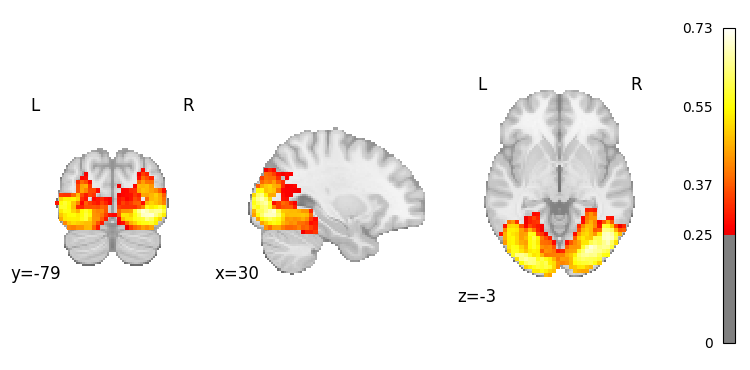

In [2]:
# Generate a brain map from a simple text query
result = nvlm.text("vision").to_brain(head="mse")

# Plot the generated activation map
result.plot(threshold=0.25);

### Access the NIfTI image

In [3]:
# Get the NIfTI image
nifti_img = result.to_nifti()[0]
print(f"Image shape: {nifti_img.shape}")
print(f"Image affine:\n{nifti_img.affine}")

Image shape: (46, 55, 46, 1)
Image affine:
[[   4.    0.    0.  -90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]


## 2. Generate Maps for Different Cognitive Concepts

### Visual Processing

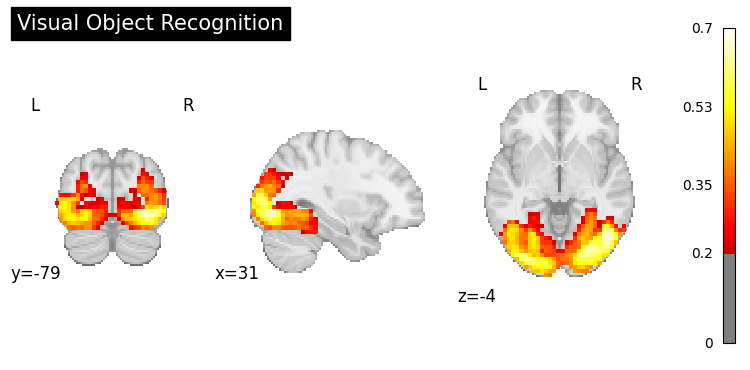

In [4]:
result = nvlm.text("visual object recognition").to_brain(head="mse")
result.plot(threshold=0.2, title="Visual Object Recognition");

### Motor Control

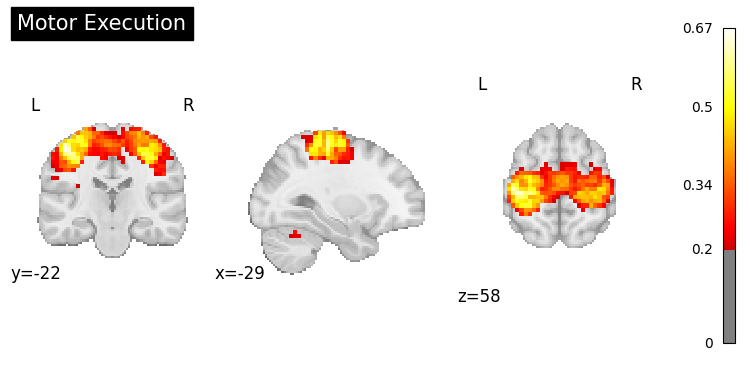

In [5]:
result = nvlm.text("motor execution").to_brain(head="mse")
result.plot(threshold=0.2, title="Motor Execution");

### Language Processing

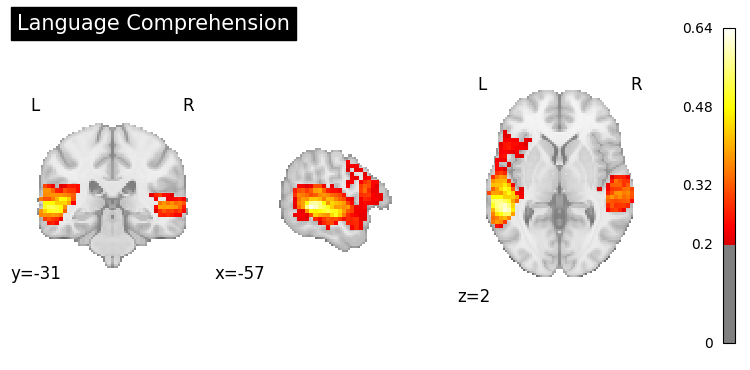

In [6]:
result = nvlm.text("language comprehension").to_brain(head="mse")
result.plot(threshold=0.2, title="Language Comprehension");

### Default Mode Network

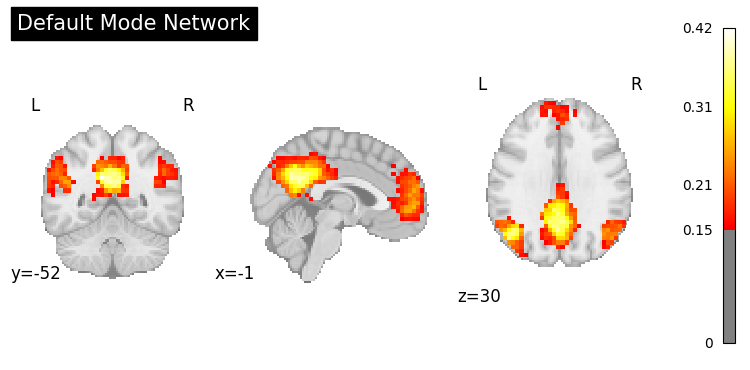

In [7]:
result = nvlm.text("default mode network").to_brain(head="mse")
result.plot(threshold=0.15, title="Default Mode Network");

### Working Memory

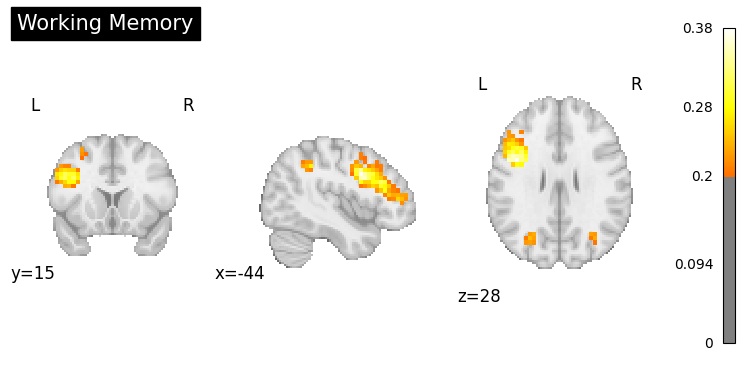

In [8]:
result = nvlm.text("working memory").to_brain(head="mse")
result.plot(threshold=0.2, title="Working Memory");

### Emotion Processing

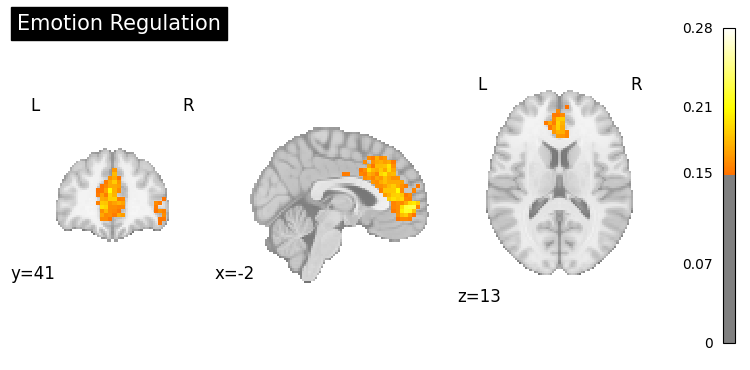

In [9]:
result = nvlm.text("emotion regulation").to_brain(head="mse")
result.plot(threshold=0.15, title="Emotion Regulation");

## 3. Batch Generation

Generate multiple brain maps at once for efficiency.

In [10]:
# Generate maps for multiple cognitive functions
queries = [
    "visual attention",
    "auditory processing"
]

result = nvlm.text(queries).to_brain(head="mse")

# Get all NIfTI images
images = result.to_nifti()
print(f"Generated {len(images)} brain maps")

Generated 2 brain maps


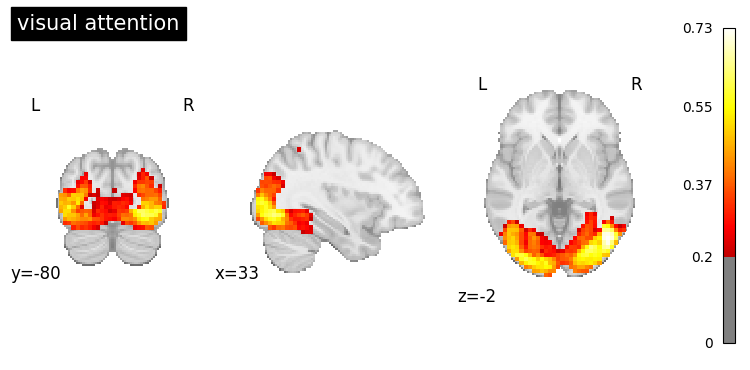

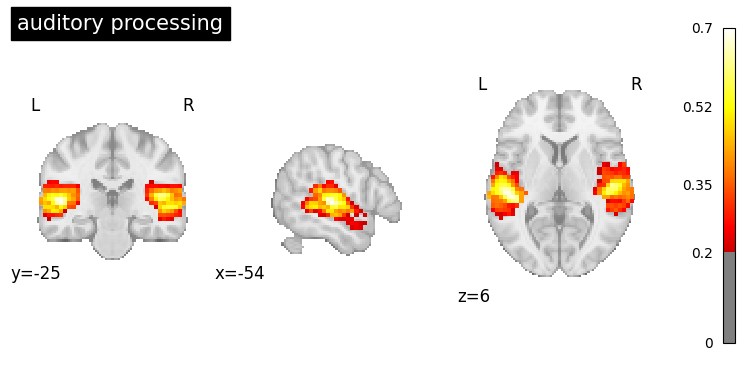

In [11]:
# Plot each generated map
for i, query in enumerate(queries):
    result.plot(index=i, threshold=0.2, title=query);

## 4. Using Scientific Abstracts

You can generate brain maps from longer, more detailed text like scientific abstracts.

PMID: 21784106
Title: Age differences in spatial working memory contributions to visuomotor adaptation  and transfer.

Abstract:
Throughout our life span we encounter challenges that require us to adapt to the demands of our changing environment; this entails learning new skills. Two primary components of motor skill learning are motor acquisition, the initial process of learning the skill, and motor transfer, when learning a new skill is benefitted by the overlap with a previously learned one. Older adults typically exhibit declines in motor acquisition compared to young adults, but remarkably, do not demonstrate deficits in motor transfer [10]. Our recent work demonstrates that a failure to engage spatial working memory (SWM) is associated with skill learning deficits in older adults [16]. Here, we investigate the role that SWM plays in both motor learning and transfer in young and older adults. Both age groups exhibited performance savings, or positive transfer, at transfer of learn

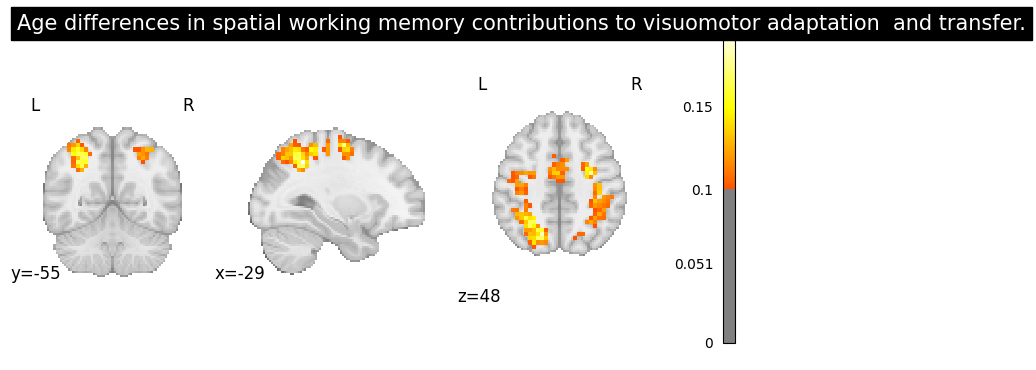

In [12]:
from neurovlm.data import load_dataset

# Load the PubMed dataset and pick a test-set example
pubmed = load_dataset("pubmed_text")
test_df = pubmed[pubmed["test"] == True].dropna(subset=["name", "description"])
row = test_df.iloc[20]

abstract = row["description"]
title = row["name"]
print(f"PMID: {row['pmid']}")
print(f"Title: {title}\n")
print(f"Abstract:\n{abstract}")

result = nvlm.text(abstract).to_brain(head="mse")
result.plot(threshold=0.1, title=title);

## 5. Saving Generated Maps

Export generated brain maps as NIfTI files for further analysis.

In [13]:
import nibabel as nib
from pathlib import Path

# Generate a brain map
result = nvlm.text("attention network").to_brain(head="mse")
nifti_img = result.to_nifti(index=0)

# Save to file
output_dir = Path("generated_maps")
output_dir.mkdir(exist_ok=True)
nib.save(nifti_img, output_dir / "attention_network.nii.gz")
print(f"Saved to {output_dir / 'attention_network.nii.gz'}")

Saved to generated_maps/attention_network.nii.gz


### Batch save multiple maps

In [14]:
# Generate multiple maps
cognitive_functions = [
    "sensorimotor processing",
    "cognitive control",
    "memory encoding",
    "reward processing"
]

result = nvlm.text(cognitive_functions).to_brain(head="mse")
images = result.to_nifti()

# Save each map
for i, (query, img) in enumerate(zip(cognitive_functions, images)):
    filename = query.replace(" ", "_") + ".nii.gz"
    nib.save(img, output_dir / filename)
    print(f"Saved: {filename}")

Saved: sensorimotor_processing.nii.gz
Saved: cognitive_control.nii.gz
Saved: memory_encoding.nii.gz
Saved: reward_processing.nii.gz


## 6. Comparing Generative vs. Retrieval

Let's compare brain maps generated from text vs. maps retrieved from datasets.

=== Generated Map ===

=== Retrieved Map ===
    dataset  dataset_index  title    description  cosine_similarity
0  networks            130  WashU  Effector-hand           0.460576


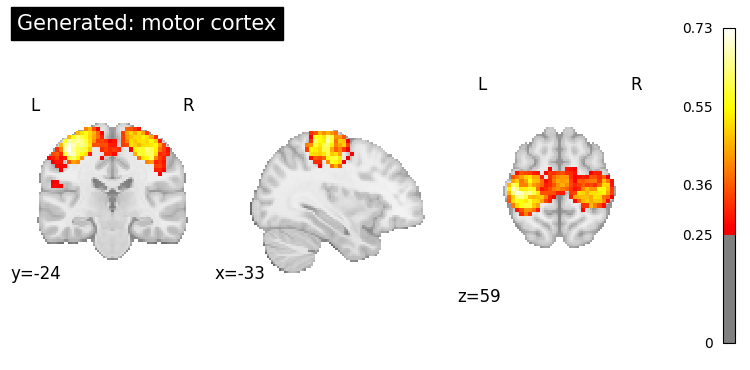

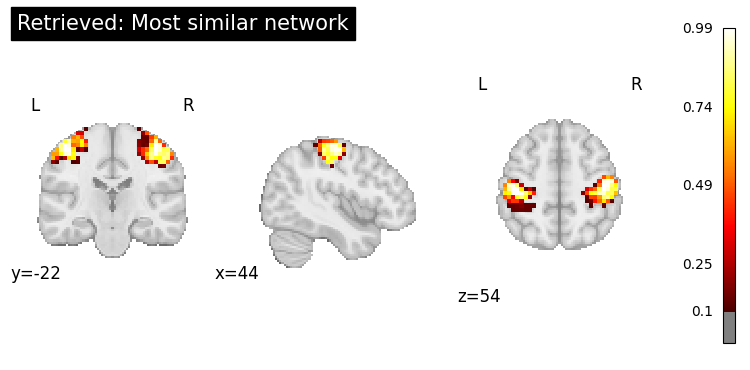

In [15]:
query = "motor cortex"

# Generate a brain map
generated = nvlm.text(query).to_brain(head="mse")

# Retrieve similar maps
retrieved = nvlm.text(query).to_brain(head="infonce", dataset="networks")

print("=== Generated Map ===")
generated.plot(threshold=0.25, title=f"Generated: {query}");

print("\n=== Retrieved Map ===")
top = retrieved.top_k(1)
print(top)
top.plot_row(0, threshold=0.1, title="Retrieved: Most similar network");

## 7. Advanced: Using Different Display Modes

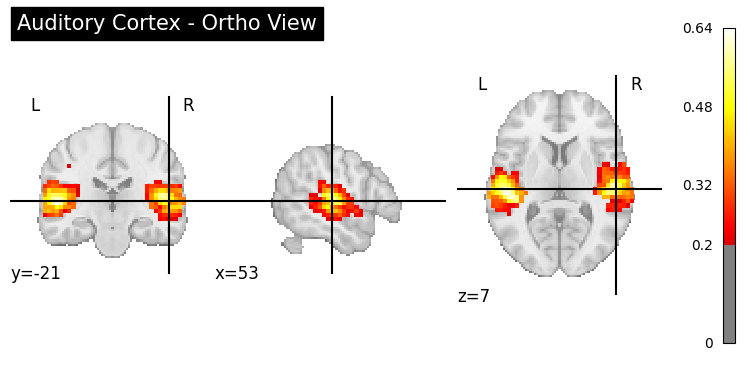

In [16]:
from nilearn import plotting

result = nvlm.text("auditory cortex").to_brain(head="mse")
img = result.to_nifti(index=0)

# Ortho view (default)
plotting.plot_stat_map(
    img, threshold=0.2, display_mode="ortho",
    title="Auditory Cortex - Ortho View", cmap="hot"
);

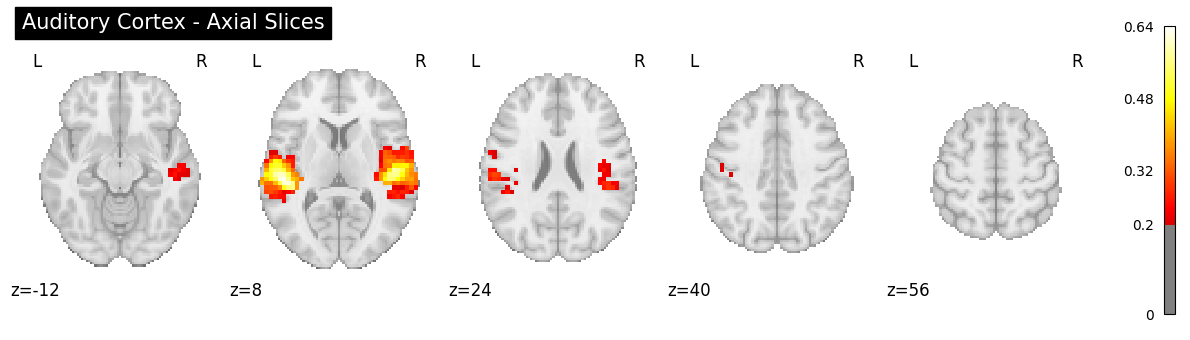

In [17]:
# Z slices
plotting.plot_stat_map(
    img, threshold=0.2, display_mode="z",
    cut_coords=5, title="Auditory Cortex - Axial Slices", cmap="hot"
);

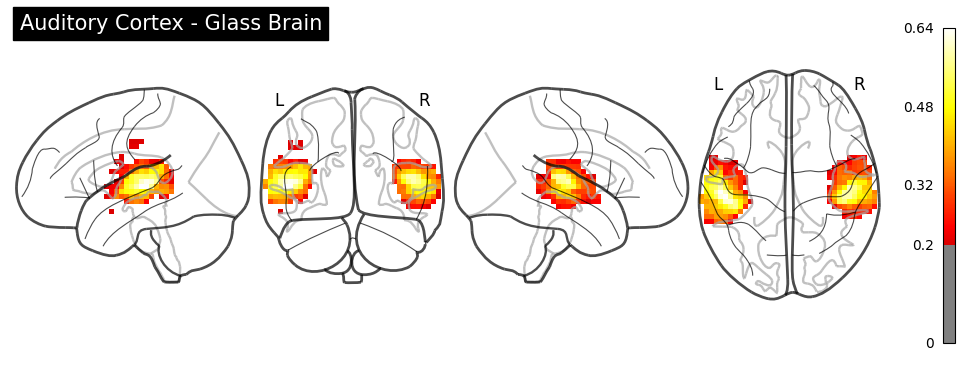

In [18]:
# Glass brain
plotting.plot_glass_brain(
    img, threshold=0.2, display_mode="lyrz",
    title="Auditory Cortex - Glass Brain", cmap="hot"
);

## 8. Exploring Specific Regions

In [19]:
result.generated_flatmaps[0].quantile(0.95)

tensor(0.1665)

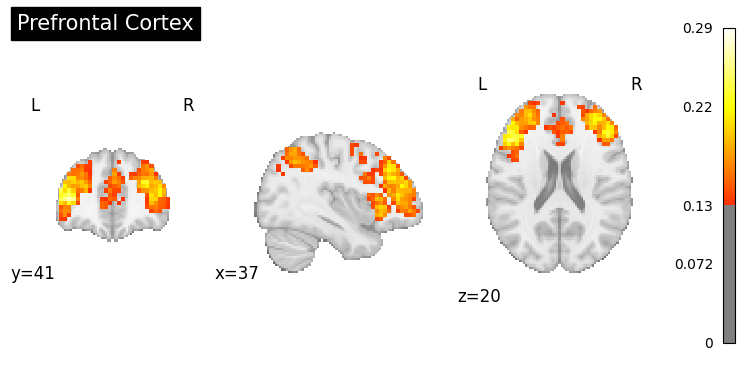

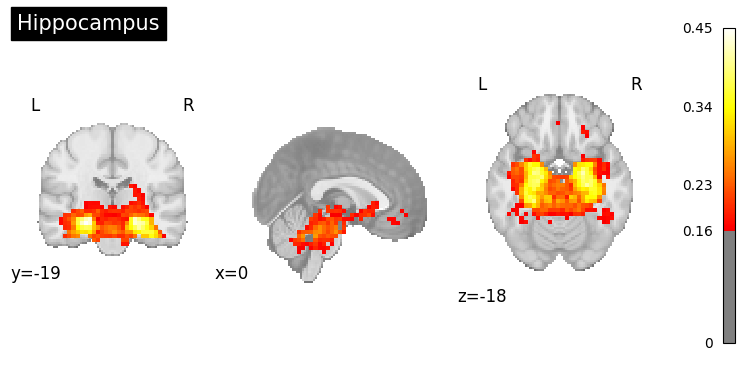

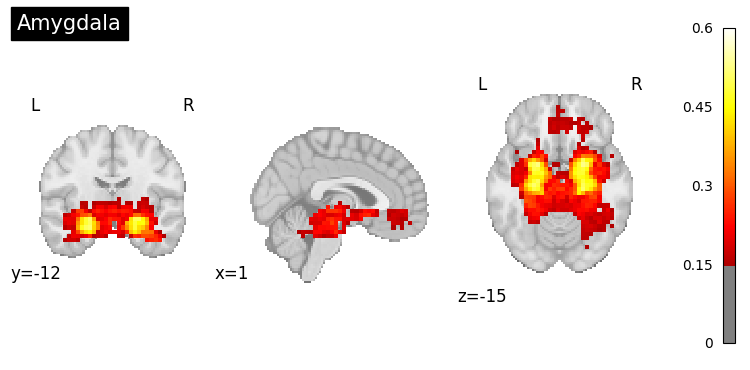

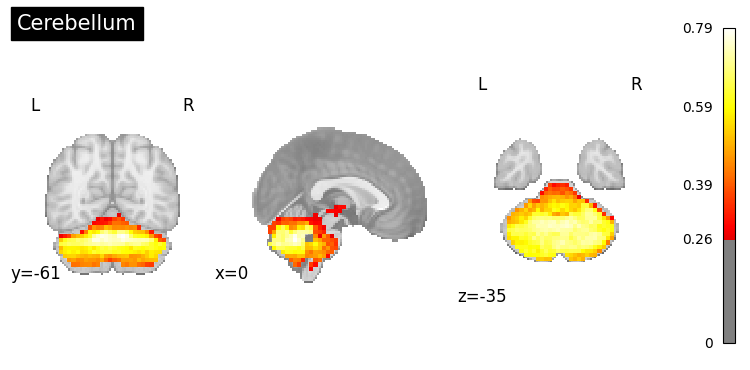

In [20]:
# Generate maps for specific brain regions
regions = [
    "prefrontal cortex",
    "hippocampus",
    "amygdala",
    "cerebellum"
]

for region in regions:
    result = nvlm.text(region).to_brain(head="mse")
    threshold = float(result.generated_flatmaps[0].quantile(0.90))
    result.plot(threshold=threshold, title=region.title());

## 9. Clinical Applications

Generate activation patterns related to clinical conditions.

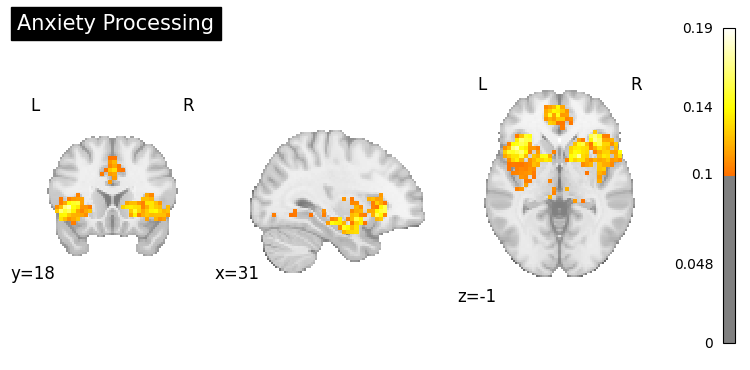

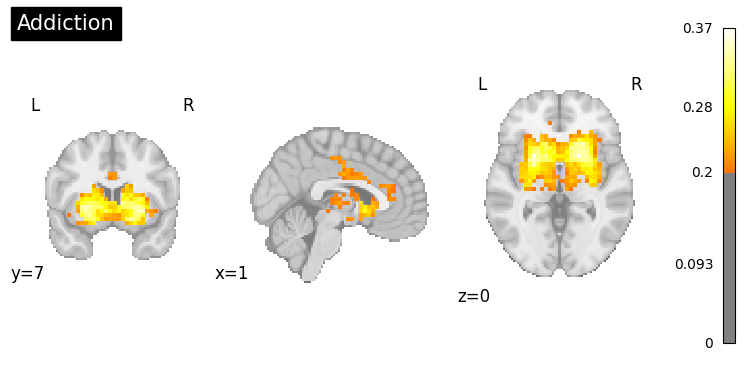

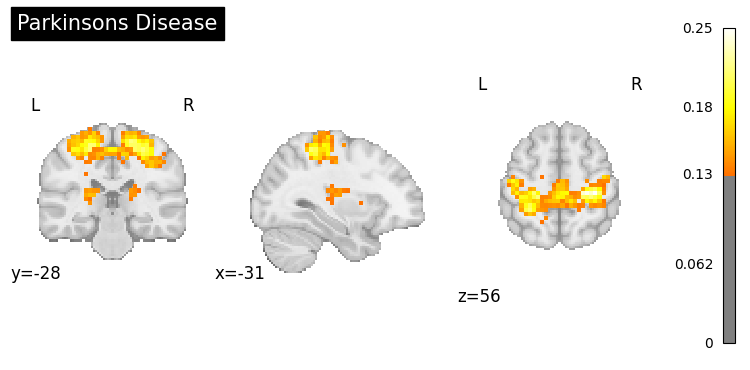

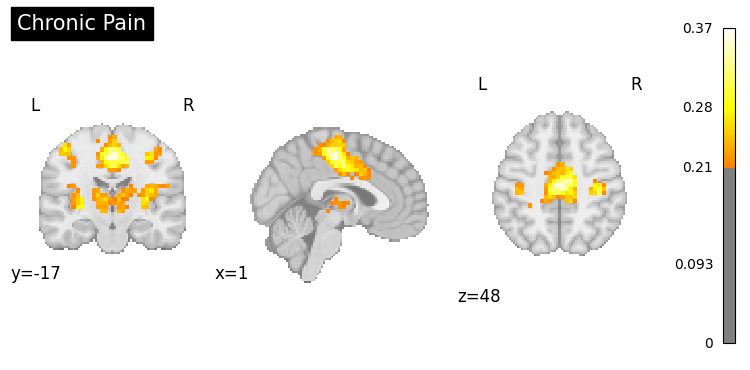

In [21]:
# Example: Disorders or symptoms
clinical_queries = [
    "anxiety processing",
    "addiction",
    "Parkinsons disease",
    "chronic pain"
]

for query in clinical_queries:
    result = nvlm.text(query).to_brain(head="mse")
    threshold = float(result.generated_flatmaps[0].quantile(0.95))
    result.plot(threshold=threshold, title=query.title());

## 10. Summary

In this tutorial, you learned:

1. **Basic text-to-brain generation** using `head="mse"`
2. **Generating maps** for various cognitive concepts:
   - Vision, motor, language, memory, emotion
3. **Batch generation** for multiple queries
4. **Using scientific abstracts** as input
5. **Saving generated maps** as NIfTI files
6. **Comparing generative vs. retrieval** approaches
7. **Visualization options** (ortho, slices, glass brain)
8. **Clinical applications**

**Key Differences**:
- **Generative (MSE)**: Creates new brain maps from text, useful for hypothesis generation
- **Retrieval (InfoNCE)**: Finds existing maps from datasets, useful for finding real examples

**Next**: In Tutorial 4, you'll learn how to generate text descriptions from brain activation maps using language models.